# Case NPS Preditivo

## O que é NPS?

**_Net Promoter Score_** (NPS) é uma métrica de lealdade e satisfação do cliente que mede a probabilidade de consumidores recomendarem uma empresa, produto ou serviço a amigos ou colegas. É formada com base em uma pergunta simples de 0 a 10, classificando clientes em promotores, neutros ou detratores.

## Cenário Atual

Com o crescimento do e-commerce nacional, a empresa passou a lidar com volume cada vez maior de pedidos, entregas e iterações com clientes, porém, esse crescimento relevou a alta variabilidade do NPS entre diferentes perfis de consumidores.

O NPS é coletado apenas após o encerramento da jornada de compora, limitando a capacidade da emrpesa de antecipar problemas, priorizar ações corretivas e atuar de forma preventiva.

## Perguntas Norteadoras
- Quais fatores operacionais realmente influenciam a satisfação do cliente?
- Como a empresa pode agir de forma proativa para melhorar a experiência antes mesmo da aplicação da pesquisa de NPS?


In [1]:
# Importação das bibliotecas para análise exploratória de dados

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

# Importação da biblioteca pickle e os para armazenar dicionário de dados

import pickle
import os

In [2]:
# Importação do dataset

nps = pd.read_csv("desafio_nps_fase_1.csv")
nps.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## Dicionário de Dados
O código a seguir tem como finalidade prover uma estrutura de dados `dict_dados` contendo a descrição de cada coluna do dataset.

In [3]:
# Célula para criar um dicionário para o conjunto de dados NPS

if os.path.exists("dict_dados.bin"):
    with open("dict_dados.bin", "rb") as file:
        dict_dados = pickle.load(file)
else:
    dict_dados = {}

# Se não existir o arquivo binário, o usuário deverá preenchê-lo

if not dict_dados:
    for c in nps.columns:
        dict_dados[c] = input(f"Digite a descrição da coluna {c}: ")

    print("Dicionário criado com sucesso: ", dict_dados)

    with open("dict_dados.bin", "wb") as file:
        pickle.dump(dict_dados, file)
else:
    print("Dicionário carregado com sucesso do arquivo binário.")

Dicionário carregado com sucesso do arquivo binário.


In [4]:
print("O conjunto de dados possui {} linhas e {} colunas.".format(*nps.shape))

O conjunto de dados possui 2500 linhas e 19 colunas.


In [5]:
# Verificação de tipos de dados que estão presente no dataset

nps.dtypes

customer_id                    int64
customer_age                   int64
customer_region               object
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object

In [6]:
# Verificação se tem dados nulos no dataset

print("Não há dados nulos no dataset.") if nps.isnull().sum().sum() == 0 else print("Há dados nulos no dataset.")

Não há dados nulos no dataset.


In [7]:
# Retirando coluna costumer_id do conjunto de dados

nps = nps.drop("customer_id", axis=1)

## Estatística Descritiva
A seguir temos a estatística descritiva das variáveis numéricas discretas e contínuas.

In [8]:
# Gera estatísticas descritivas e transpõe o resultado (.T) para facilitar a visualização das variáveis como linhas

nps.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_age,2500.0,43.396000,14.888487,18.00,31.0000,43.000,56.0000,69.00
customer_tenure_months,2500.0,61.322400,34.478729,1.00,31.0000,62.000,91.0000,119.00
order_id,2500.0,51250.500000,721.832160,50001.00,50625.7500,51250.500,51875.2500,52500.00
order_value,2500.0,434.259740,289.772497,7.76,220.2450,375.515,577.2900,1983.81
items_quantity,2500.0,3.470800,1.687331,1.00,2.0000,3.000,5.0000,6.00
discount_value,2500.0,29.745620,29.225603,0.02,8.8850,20.935,40.8325,230.33
payment_installments,2500.0,6.004000,3.159743,1.00,3.0000,6.000,9.0000,11.00
delivery_time_days,2500.0,8.022000,3.770411,2.00,5.0000,8.000,11.0000,14.00
delivery_delay_days,2500.0,2.187200,1.454442,0.00,1.0000,2.000,3.0000,8.00
freight_value,2500.0,38.217016,12.076074,2.62,29.9275,38.500,46.2700,76.13


In [9]:
# Acessa a coluna 'delivery_delay_days' no dicionário

dict_dados["delivery_delay_days"]

'Quantidade de dias de atraso na entrega'

In [10]:
# Acessa a coluna 'delivery_time_days' no dicionário

dict_dados["delivery_time_days"]

'Tempo total de entrega (em dias)'

## Classificação NPS
- Promotores (9-10): Clientes satisfeitos que indicam a marca;
- Neutros (7-8): Clientes passivos, satisfeitos, mas não leais;
- Detratores (0-6): Clientes insatisfeitos que podem prejudicar a marca.

In [11]:
# Função de classificação para NPS

def nps_class(df):
    if df["nps_score"] >= 9: return 'Promotor'
    elif df["nps_score"] >= 7: return 'Neutro'
    else: return 'Detrator'

In [12]:
# Cria a coluna 'classe' no DataFrame 'nps' aplicando a função 'nps_class' a cada linha

nps["classe"] = nps.apply(nps_class, axis=1)

In [13]:
# Conta a quantidade de ocorrências de cada valor na coluna 'classe'

nps["classe"].value_counts()

classe
Detrator    2109
Neutro       281
Promotor     110
Name: count, dtype: int64

In [14]:
# Calcula um resumo estatístico da coluna 'nps_score' para entender sua distribuição

nps["nps_score"].describe()

count    2500.000000
mean        4.378600
std         2.510229
min         0.000000
25%         2.600000
50%         4.400000
75%         6.100000
max        10.000000
Name: nps_score, dtype: float64

Concluímos que aproximadamente 75% dos clientes são detratores. Agora, vamos averiguar por que são detratores e quais fatores diferem para os outros 25% dos clientes.

## Gráfico boxplot e histograma para NPS Score

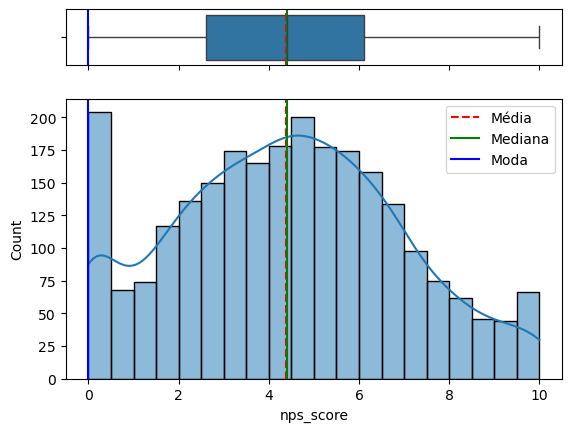

In [15]:
# Seaborn para gráfico de boxplot e histograma da variável nps_score

f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw= {"height_ratios": (0.2, 1)})
mean=nps["nps_score"].mean()
median=nps["nps_score"].median()
mode=nps["nps_score"].mode().values[0]

sns.boxplot(data=nps, x="nps_score", ax=ax_box)
ax_box.axvline(mean, color='r', linestyle='--')
ax_box.axvline(median, color='g', linestyle='-')
ax_box.axvline(mode, color='b', linestyle='-')

sns.histplot(data=nps, x="nps_score", ax=ax_hist, kde=True)
ax_hist.axvline(mean, color='r', linestyle='--', label="Média")
ax_hist.axvline(median, color='g', linestyle='-', label="Mediana")
ax_hist.axvline(mode, color='b', linestyle='-', label="Moda")

plt.legend()

ax_box.set(xlabel='')
plt.show()

Observa-se que Moda < Mediana < Moda, logo temos uma pequna assimétria positiva (à direita.) Segundo o boxplot, não há outliers.

In [16]:
# Analisa o perfil dos clientes mais insatisfeitos (nota 0 no NPS)

nps[nps["nps_score"] <= 0].describe().T

,count,mean,std,min,25%,50%,75%,max
customer_age,158.0,44.645570,13.720632,18.00,35.0000,45.500,56.7500,69.00
customer_tenure_months,158.0,61.715190,33.793696,1.00,34.2500,61.500,89.7500,118.00
order_id,158.0,51167.993671,645.949876,50008.00,50611.7500,51159.000,51737.0000,52454.00
order_value,158.0,417.211203,281.148379,14.58,218.5475,368.575,526.8625,1842.30
items_quantity,158.0,3.322785,1.640526,1.00,2.0000,3.000,5.0000,6.00
discount_value,158.0,28.307468,25.820934,0.10,8.7800,20.920,41.7775,129.59
payment_installments,158.0,6.094937,3.117217,1.00,3.0000,6.000,9.0000,11.00
delivery_time_days,158.0,8.164557,3.855447,2.00,5.0000,8.000,12.0000,14.00
delivery_delay_days,158.0,4.107595,1.482748,1.00,3.0000,4.000,5.0000,8.00
freight_value,158.0,39.106456,12.022180,6.13,30.1800,40.285,47.2225,66.87


In [17]:
dict_dados["customer_tenure_months"]

'Tempo de relacionamento do cliente com a empresa (em meses)'

In [18]:
dict_dados["csat_internal_score"]

'Score interno de satisfação do cliente'

## Análise por Região
Iremos criar um novo conjunto de dados para conferir se há alguma difereça discrepante de NPS Score por região.

In [19]:
# Calcula o NPS médio por região para identificar diferenças de satisfação entre localidades

df_nps_regiao = pd.DataFrame(nps.groupby("customer_region")["nps_score"].mean().reset_index()) 
df_nps_regiao

,customer_region,nps_score
0,Centro-Oeste,4.209829
1,Nordeste,4.421649
2,Norte,4.382609
3,Sudeste,4.373846
4,Sul,4.490979


## Gráfico de Barras Região x NPS Score

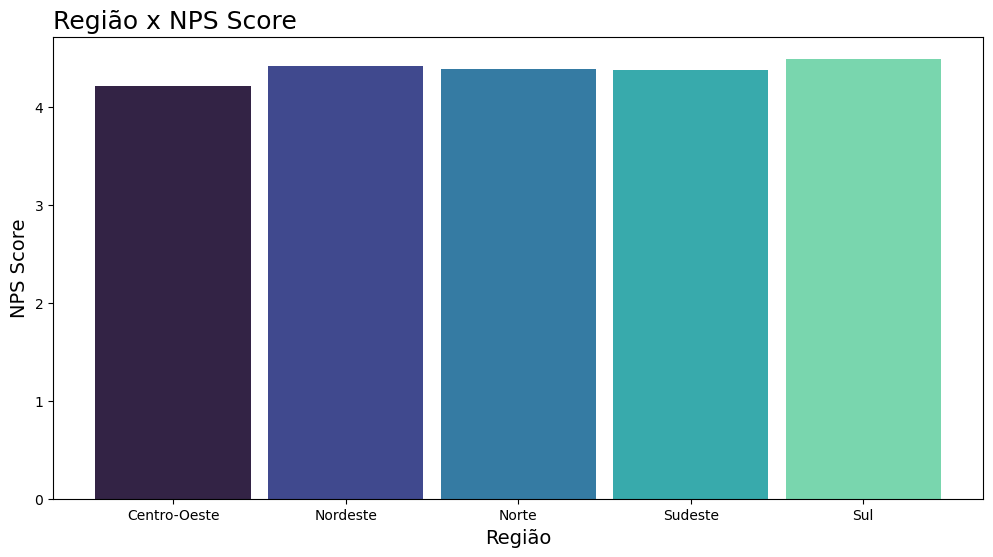

In [20]:
# Matplotlib para gráfico de barras

plt.figure(figsize=(12,6))

color_palette = sns.color_palette("mako", len(df_nps_regiao))

plt.bar(df_nps_regiao["customer_region"], 
        df_nps_regiao["nps_score"],
        width=0.9,
        color=color_palette)

plt.title("Região x NPS Score", loc = "left", fontsize = 18)

plt.xlabel("Região", fontsize = 14)
plt.ylabel("NPS Score", fontsize = 14)


plt.show()

Não há diferença significativa entre regiões. Vamos descartar a variável customer_region para as seguintes análises.

In [21]:
nps = nps.drop("customer_region", axis=1)

In [22]:
# Verificação se a variável 'customer_region' foi descartada

nps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_age               2500 non-null   int64  
 1   customer_tenure_months     2500 non-null   int64  
 2   order_id                   2500 non-null   int64  
 3   order_value                2500 non-null   float64
 4   items_quantity             2500 non-null   int64  
 5   discount_value             2500 non-null   float64
 6   payment_installments       2500 non-null   int64  
 7   delivery_time_days         2500 non-null   int64  
 8   delivery_delay_days        2500 non-null   int64  
 9   freight_value              2500 non-null   float64
 10  delivery_attempts          2500 non-null   int64  
 11  customer_service_contacts  2500 non-null   int64  
 12  resolution_time_days       2500 non-null   int64  
 13  nps_score                  2500 non-null   float

## Respondendo a primeira pergunta norteadora
Quais fatores operacionais realmente influenciam a satisfação do cliente?

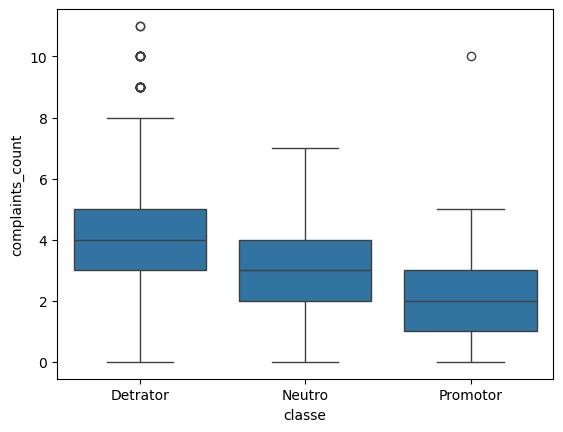

In [23]:
ax = sns.boxplot(x="classe", y="complaints_count", data=nps)

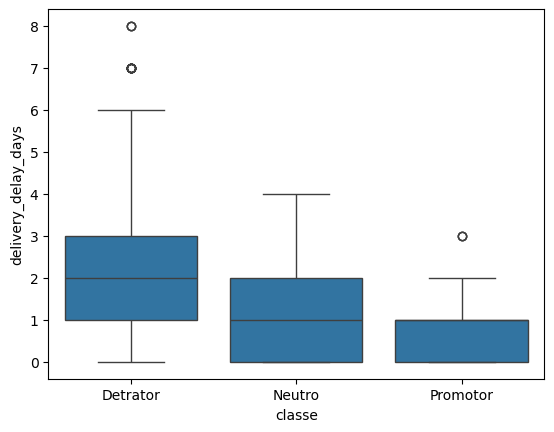

In [24]:
ax = sns.boxplot(x="classe", y="delivery_delay_days", data=nps)

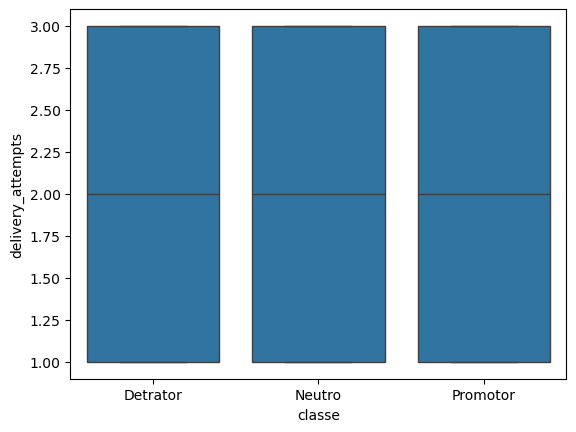

In [25]:
ax = sns.boxplot(x="classe", y='delivery_attempts', data=nps)

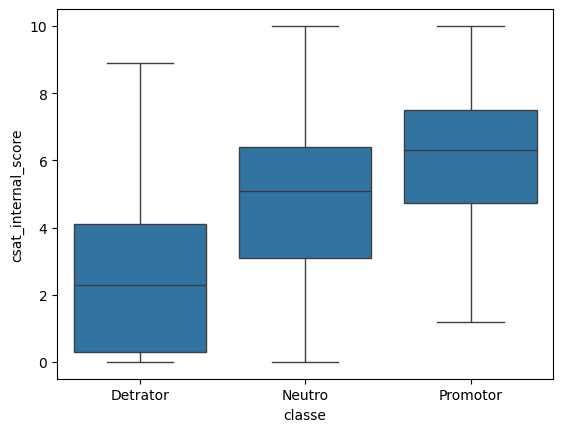

In [26]:
ax = sns.boxplot(x="classe", y="csat_internal_score", data=nps)

In [27]:
# Cria um subconjunto do DataFrame 'nps' com variáveis operacionais e de satisfação

nps_filtered = nps[["complaints_count", "delivery_delay_days", "customer_service_contacts", "csat_internal_score", "classe"]]

In [28]:
# Verifica a estrutura dos dados selecionados para análise

nps_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   complaints_count           2500 non-null   int64  
 1   delivery_delay_days        2500 non-null   int64  
 2   customer_service_contacts  2500 non-null   int64  
 3   csat_internal_score        2500 non-null   float64
 4   classe                     2500 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 97.8+ KB


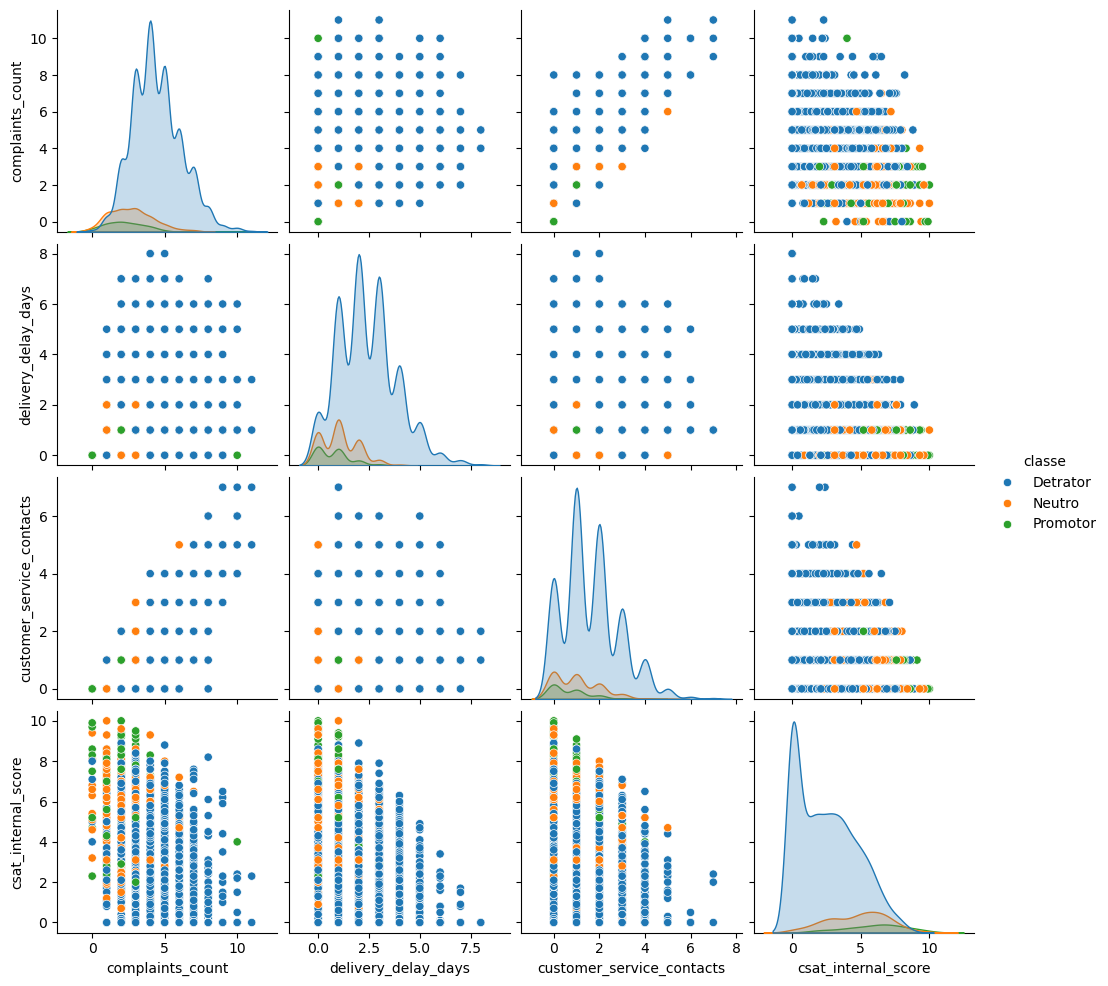

In [29]:
# Define as variáveis quantitativas que serão analisadas

variáveis_quanti = ["complaints_count", "delivery_delay_days", "customer_service_contacts", "csat_internal_score"]

sns.pairplot(
    nps_filtered,
    vars=variáveis_quanti,  # Especifica as variáveis quantitativas
    hue='classe'  # Colore os pontos com base na variável 'Classe'
);

Conclusão e Próximos Passos

A análise exploratória permitiu identificar os principais padrões relacionados ao NPS e direcionar o foco para variáveis com maior impacto na satisfação dos clientes. Em geral, os dados se mostraram consistentes e sem anomalias relevantes, garantindo confiabilidade nas análises realizadas.

Foi possível observar que alguns fatores, como a região que não apresentam influência significativa no NPS, enquanto outros indicadores operacionais demonstraram maior potencial para explicar níveis de satisfação, especialmente nos casos de clientes detratores.

Próximos Passos

-Desenvolver e comparar modelos de machine learning preditivo, antecipando o comportamento dos clientes
-Estruturar um ciclo contínuo de monitoramento e otimização da satisfação dos clientes
-Implementar um sistema que permita antecipar a satisfação do cliente, possibilitando ações proativas
-Priorizar iniciativas com maior potencial de impacto na experiência do cliente
-Enriquecimento do dataset